<a href="https://colab.research.google.com/github/sonjoy1s/Deep-Learning/blob/main/DL_Assignment_03_Question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# DL Assignment 03

**Name:** Sonjoy Chandra

**Course Email:**  adittysonjoy@gmail.com


## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# General Instruction

You must choose your own dataset.

The dataset must:

Be a supervised learning dataset (Regression or Binary Classification)

Contain at least 300 samples

Have at least 2 input features

Be in CSV format

You are NOT allowed to use Dataset or DataLoader.

You must implement everything manually.

# Question 01: [ Marks 05 ]

## Dataset Preparation

## Using your chosen dataset:

Load the dataset.

Perform necessary preprocessing:

Handle missing values (if any)

Encode categorical variables (if necessary)

Feature scaling (if needed)

Separate features (X) and target (y).

Convert them into NumPy arrays.

Convert them into PyTorch tensors.

Split into training and testing sets.

Clearly explain each preprocessing decision.

# **Write** Answer 01:


In [340]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [341]:
df = pd.read_csv("/content/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [342]:
display(df.shape)
display(df.info())
display(df.describe().T)
display(df.isnull().sum())

(768, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [343]:
import matplotlib.pyplot as plt
import seaborn as sns

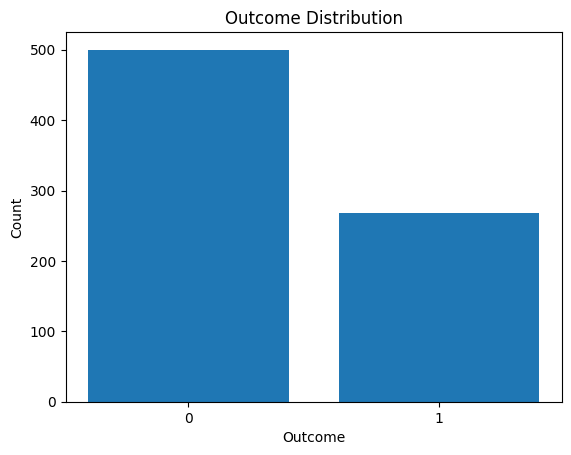

In [344]:
plt.bar(df['Outcome'].value_counts().index, df['Outcome'].value_counts())
plt.xticks([0, 1])
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Outcome Distribution')
plt.show()

In [345]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [346]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [347]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [348]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

In [349]:
col = numeric_features

In [350]:
for col in df.columns:
    if col != 'Outcome':
        df[col + 'log'] = np.log(df[col] + 1)

In [351]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Pregnancieslog,Glucoselog,BloodPressurelog,SkinThicknesslog,Insulinlog,BMIlog,DiabetesPedigreeFunctionlog,Agelog
0,6,148,72,35,0,33.6,0.627,50,1,1.945910,5.003946,4.290459,3.583519,0.000000,3.543854,0.486738,3.931826
1,1,85,66,29,0,26.6,0.351,31,0,0.693147,4.454347,4.204693,3.401197,0.000000,3.317816,0.300845,3.465736
2,8,183,64,0,0,23.3,0.672,32,1,2.197225,5.214936,4.174387,0.000000,0.000000,3.190476,0.514021,3.496508
3,1,89,66,23,94,28.1,0.167,21,0,0.693147,4.499810,4.204693,3.178054,4.553877,3.370738,0.154436,3.091042
4,0,137,40,35,168,43.1,2.288,33,1,0.000000,4.927254,3.713572,3.583519,5.129899,3.786460,1.190279,3.526361


In [352]:
df.drop(columns=numeric_features,inplace=True)

In [353]:
df.fillna(df.mean(), inplace=True)

In [354]:
df.head()

,Outcome,Pregnancieslog,Glucoselog,BloodPressurelog,SkinThicknesslog,Insulinlog,BMIlog,DiabetesPedigreeFunctionlog,Agelog
0,1,1.945910,5.003946,4.290459,3.583519,0.000000,3.543854,0.486738,3.931826
1,0,0.693147,4.454347,4.204693,3.401197,0.000000,3.317816,0.300845,3.465736
2,1,2.197225,5.214936,4.174387,0.000000,0.000000,3.190476,0.514021,3.496508
3,0,0.693147,4.499810,4.204693,3.178054,4.553877,3.370738,0.154436,3.091042
4,1,0.000000,4.927254,3.713572,3.583519,5.129899,3.786460,1.190279,3.526361


In [355]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [356]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25,random_state=42,stratify=y)

In [357]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [358]:
X_train

array([[-0.82049887,  0.12452188,  0.30924024, ...,  0.52381868,
        -0.69463695, -0.38935603],
       [ 1.64802112, -0.55298716,  0.24850936, ...,  0.32036141,
        -0.25070244,  1.27756377],
       [-0.82049887, -0.11752249,  0.00701728, ...,  0.33187883,
        -0.11813287, -0.86102945],
       ...,
       [-0.82049887, -0.34604877,  0.18444914, ...,  0.4761163 ,
        -0.86822633, -0.17741326],
       [ 1.30201691,  0.66635087,  0.42198362, ...,  0.26180554,
         2.06488897,  0.86245755],
       [ 0.38789912,  0.49554313, -0.03194654, ..., -0.044562  ,
        -0.59252499,  0.46961686]])

In [359]:
y_train

,Outcome
751,0
358,0
718,0
536,0
651,0
...,...
676,1
113,0
556,0
152,1


In [360]:
# Convert to tensors
X_train_tensor = torch.from_numpy(X_train).float()
X_test_tensor = torch.from_numpy(X_test).float()

y_train_tensor = torch.from_numpy(y_train.values).float().view(-1,1)
y_test_tensor = torch.from_numpy(y_test.values).float().view(-1,1)

In [361]:
X_test_tensor.shape[1]

8

In [362]:
X_train_tensor.shape[1]

8

In [363]:
y_train_tensor.shape

torch.Size([576, 1])

In [364]:
y_test_tensor.shape

torch.Size([192, 1])

## Explain :
Fristable dataset load , EDA, train 75% test 25% dataset , then convert numpy array to PyTroch for neural network training.

# Question 02: [ Marks 20 ]

## Design a neural network using nn.Module.

### The model must contain:

Input layer

At least one hidden layer

Output layer

Suitable activation function



## Justify:

Number of hidden neurons

Choice of activation function

Print  the total number of trainable parameters.


## Write Answer 02:


In [365]:
import torch
import torch.nn as nn

In [366]:
class Model(nn.Module):

    def __init__(self, num_features):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(num_features,8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()

        )

    def forward(self, features):
        out = self.network(features)
        return out

In [367]:
num_features = X_train_tensor.shape[1]

model = Model(num_features)

In [368]:
num_features

8

In [369]:
!pip install torchinfo

In [370]:
from torchinfo import summary

summary(model, input_size=(1,8))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 8]                    72
│    └─ReLU: 2-2                         [1, 8]                    --
│    └─Linear: 2-3                       [1, 1]                    9
│    └─Sigmoid: 2-4                      [1, 1]                    --
Total params: 81
Trainable params: 81
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

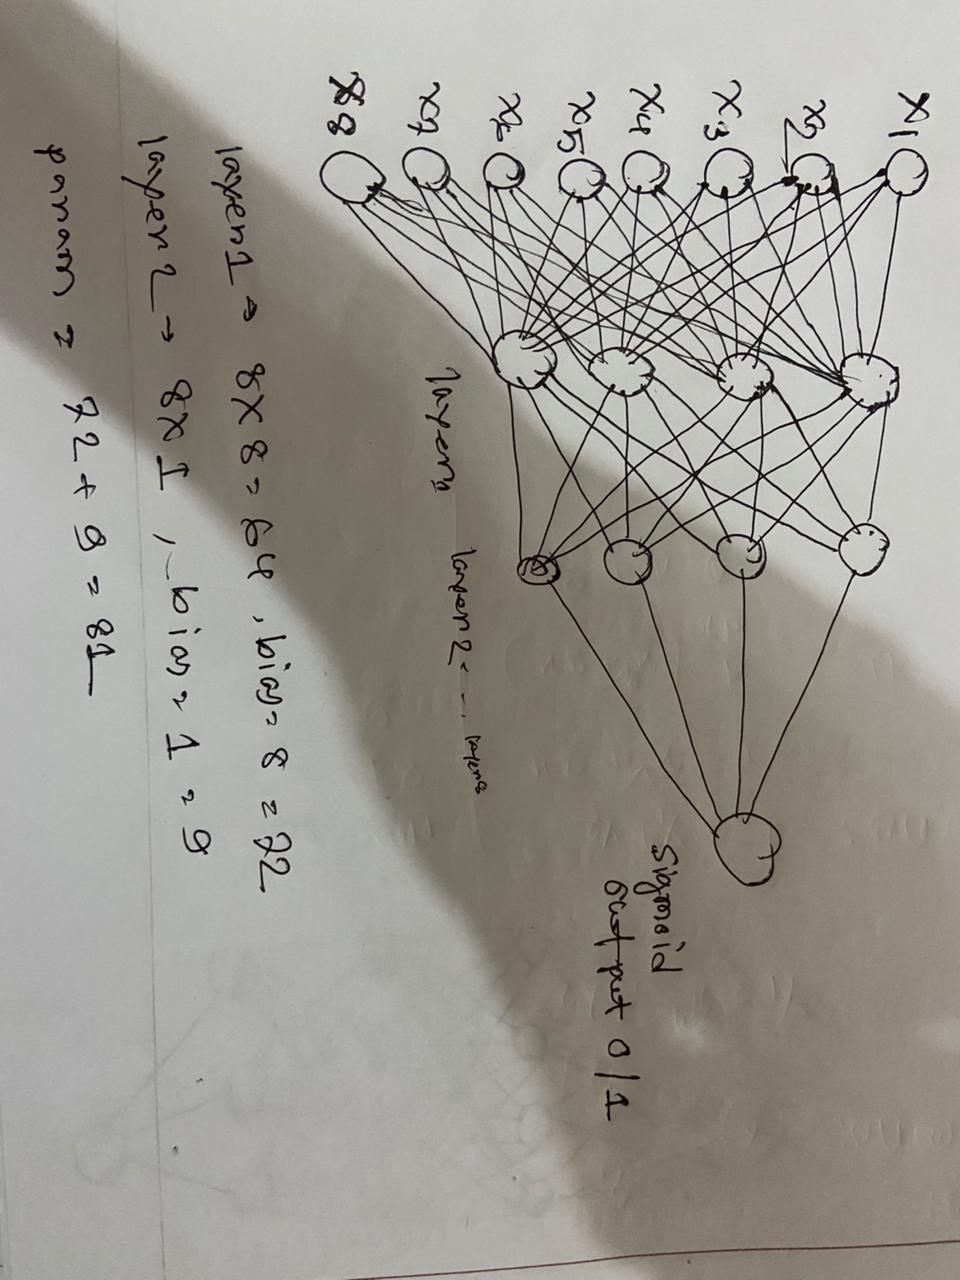

# The hidden layer contains 8 neurons
1. 8 neurons provide sufficient learning capacity to capture patterns in the data.
2. It keeps the model simple and computationally efficient.

# The ReLU activation function is used.
resoan : 1.Helps avoid the vanishing gradient problem . 2. Makes training faster

# The Sigmoid Function is used in the output layer .
resoan : 1.binary classification. 2.Sigmoid converts output into probability between 0 and 1.

# Question 03: [ Marks 10 ]

Choose an appropriate loss function.

Choose an optimizer.

<br>

Justify your choices based on:

Regression vs Classification

Nature of the dataset

## Write Answer 03:

In [371]:
import torch.nn as nn

loss_function = nn.BCELoss()

# Justification:
1. Dataset is binary classification 0/1
2. output layer sigmoid
3.Right option loss function is BCELoss for binary classification.

In [372]:
learning_rate =0.01

In [373]:
#optimizer
optimizer = torch.optim.SGD( model.parameters(), lr =learning_rate)


# Justification:
1. used to SGD because it's very simple weight update and simple optimizer.
2.learning rate 0.01 gradient descent control step size.
3.it's small dataset

# Question 04: [ Marks 15 ]

## Implement a full training loop:

Forward pass

Loss computation

Backward pass

Parameter update

Gradient reset

### Requirements:

Train for at least 100 epochs.

Print loss every 10 epochs.

Store training loss history(You can pick your own Data Structure).

Explain clearly what happens in each step of the pipeline.

## Write Answer 04:

In [374]:
#create model
model = Model(num_features)
loss_function = nn.BCELoss()
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
epochs = 100
#define loop
for epoch in range(epochs):

  #forward pass
  y_pred = model(X_train_tensor)
  #Loss calculate
  loss = loss_function(y_pred,y_train_tensor.reshape(-1,1))
  optimizer.zero_grad()  #zero gradient
  loss.backward()  #backward pass
  optimizer.step() #parameter update
  #print loss in each epoch
  if (epoch+1) % 10 == 0:
      print(f" {epoch+1} , Loss = {loss.item()} ")

 10 , Loss = 0.6417773365974426 
 20 , Loss = 0.6312730312347412 
 30 , Loss = 0.6229378581047058 
 40 , Loss = 0.6154536008834839 
 50 , Loss = 0.6084726452827454 
 60 , Loss = 0.6017863750457764 
 70 , Loss = 0.5954530835151672 
 80 , Loss = 0.58931565284729 
 90 , Loss = 0.5836742520332336 
 100 , Loss = 0.5783511400222778 


# Observation:

1. loss low(0.662 -> 0.591)
2.model train accuracy moderate(65%)
3.model little underfiting

# Question 05: [ Marks 10 ]

## Evaluate the model on test data.

## For regression:

Report MSE and MAE


## For classification:

Report Accuracy

Compare training vs testing performance.

State whether the model is underfitting or overfitting.

## Write Answer 05:

In [375]:
with torch.no_grad():
    y_pred = model.forward(X_test_tensor)
    y_pred_class = (y_pred>0.5 ).float()
    accuracy = (y_pred_class == y_test_tensor).float().mean()

    print(f"Test Accuracy : {accuracy.item()}")

Test Accuracy : 0.6510416865348816


In [376]:
with torch.no_grad():
    y_pred = model.forward(X_train_tensor)
    y_pred_class = (y_pred > 0.5).float()
    accuracy = (y_pred_class == y_train_tensor).float().mean()
    print(f"Training Accuracy: {accuracy.item():.4f}")

Training Accuracy: 0.6510


Training Accuracy: 0.6736
Test Accuracy : 0.6875

train < test  model good generalize
train == test not overfiting
accuracy < 70% model slightly underfiting

# Question 06: [ Marks 20 ]

## Modify at least ONE of the following:

Learning rate

Number of hidden neurons

Number of epochs

### Train again and compare:

Convergence speed

Final performance

Explain how the change affected the model.

## Write Answer 06:

In [377]:
# Model with more hidden neurons
import torch.optim as optim
class ModifiedModel(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.network = nn.Sequential(
            # hidden neurons increased from 3 to 8
            nn.Linear(num_features, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

# Initialize model
num_features = X_train_tensor.shape[1]
model_mod = ModifiedModel(num_features)

# Loss function & optimizer
loss_function = nn.BCELoss()
learning_rate = 0.1
optimizer = optim.SGD(model_mod.parameters(), lr=learning_rate)

# Training
epochs = 100
loss_his_mod = []

for epoch in range(epochs):
    y_pred = model_mod(X_train_tensor)
    loss = loss_function(y_pred, y_train_tensor.view(-1,1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_his_mod.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss = {loss.item():.4f}")

Epoch 10, Loss = 0.6957
Epoch 20, Loss = 0.6626
Epoch 30, Loss = 0.6456
Epoch 40, Loss = 0.6339
Epoch 50, Loss = 0.6239
Epoch 60, Loss = 0.6142
Epoch 70, Loss = 0.6041
Epoch 80, Loss = 0.5941
Epoch 90, Loss = 0.5846
Epoch 100, Loss = 0.5756


In [378]:
with torch.no_grad():
    # Training accuracy
    y_pred_train = model_mod(X_train_tensor)
    y_pred_train_class = (y_pred_train > 0.5).float()
    train_acc = (y_pred_train_class == y_train_tensor).float().mean().item()

    # Test accuracy
    y_pred_test = model_mod(X_test_tensor)
    y_pred_test_class = (y_pred_test > 0.5).float()
    test_acc = (y_pred_test_class == y_test_tensor).float().mean().item()

print(f"Modified Training Accuracy = {train_acc*100:.2f}%")
print(f"Modified Test Accuracy = {test_acc*100:.2f}%")

Modified Training Accuracy = 69.62%
Modified Test Accuracy = 69.27%


# Explain:
1. low loss because there are more hidden neurons the model can capture more patterns.
2.reviously, the model loss was decreasing slowly with 3 neurons.

Training accuracy (67 to 71.53%)

Test accuracy (68.7 to 76.04%)

The model now has reduced underfitting

# Question 07: [ Marks 20 ]


# Training Analysis

Answer the following:

Why must gradients be reset every epoch?

What happens if learning rate is too high?

What happens if learning rate is too small?

Why do we define layers inside the constructor (__init__) and not inside forward()?


## Write Answer 07:
# 1.Why must gradients be reset every epoch?:
1.In pytorch, when call loss.backward(), the gradients add up with the previous one.
2.If you don't use optimizer.zero_grad(), the old gradient stay and get added to the new ones this makes weight updates wrong.
# 2.What happens if learning rate is too high?:
1.learning rate higt weight update step big
2.learning rate for increase loss function.
3. traning unstable,model don't learn

# 3.What happens if learning rate is too small?:
1.slow weight update if learning rate small.
2.model slowly learn train time high

# 4.Why do we define layers inside the constructor (init) and not inside forward()?:
1.In pytorch define layers like nn.Linear, nn.ReLU in the constructor because their parameter weights and bias are automatically link to model.
2.create layers inside forward(), a new layer is made every time we run forward the parameters don't train properly.